# Modelo Prescritivo

## Funções dos Modelos

- **Modelo preditivo** → estima probabilidades  
- **Modelo prescritivo** → toma decisão ótima com base nessas probabilidades  

## Perguntas que cada UM responde

- **Preditivo**: “Qual a chance?”  
- **Prescritivo**: “O que eu devo fazer?”  

## Ferramenta utilizada

Vamos utilizar  **Otimização Linear Inteira Binária** - 
- Usa equações lineares;
- Busca maximizar ou minimizar algo;
- Só permite decisões 0 ou 1.


In [ ]:
# import pulp

# videos = ['A','B','C']
# probabilidades = [0.72,0.65,0.40]



# Integração entre Modelo Preditivo e Modelo Prescritivo

## Objetivo

O objetivo desta etapa foi integrar o modelo preditivo (Random Forest) ao modelo prescritivo (Otimização com PuLP), mantendo uma arquitetura modular e organizada.

---

## Estrutura do Projeto

O projeto foi dividido em dois módulos:

- `predictive_model.py` → Responsável por treinar o modelo e gerar probabilidades.
- `prescriptive_model.ipynb` → Responsável por utilizar essas probabilidades para tomar a melhor decisão via otimização matemática.

Essa separação permite reutilização de código e melhor organização do sistema.

---

## Como a Integração Foi Feita

Para importar o modelo preditivo dentro do notebook prescritivo, foi necessário adicionar dinamicamente o diretório ao caminho de execução do Python:

```python
import sys
import os

# Adiciona a pasta do modelo preditivo ao path do Python
sys.path.append(os.path.abspath("../predictive-model"))

from predictive_model import (
    recomendar_top_n,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo
)

## Carregando o Modelo Preditivo

Aqui adicionamos o diretório do modelo preditivo ao path do sistema e importamos:

- `recomendar_top_n`: função que retorna os vídeos mais prováveis
- `modelo`: modelo treinado
- `le_titulo`, `le_proximo`, `le_periodo`: codificadores utilizados no treinamento

In [44]:
## IMPORTAÇÕES

import sys
import os
import pulp
import matplotlib.pyplot as plt
import pandas as pd


## CARREGANDO RESULTADOS DO MODELO PREDITIVO
sys.path.append(os.path.abspath("../predictive-model"))

from predictive_model import (
    recomendar_top_n,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo
)

In [45]:
video_atual = le_titulo.classes_[0]
periodo = "noite"

resultado = recomendar_top_n(
    video_atual,
    periodo,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo,
    n=3
)

if not resultado:
    print("Nenhuma recomendação encontrada.")
else:
    print("Top-N vindo do modelo:")
    for v, p in resultado:
        print(f"{v} → {p:.2%}")

Top-N vindo do modelo:
https://music.youtube.com/watch?v=CNDYWba7YDY → 45.00%
https://music.youtube.com/watch?v=V3NbrjVPIHM → 18.00%
https://music.youtube.com/watch?v=KjteCvkh0B8 → 16.00%


C:\Users\leticiasilva-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [46]:
#Problema 
prob=pulp.LpProblem("Recomendacao",pulp.LpMaximize)
print(prob)


Recomendacao:
MAXIMIZE
None
VARIABLES



## Teste Inicial de Recomendação

Selecionamos:

- Um vídeo atual
- Um período do dia

E utilizamos a função `recomendar_top_n()` para obter as 3 recomendações com maiores probabilidades.

Se houver resultados, exibimos:
- Nome do vídeo recomendado
- Probabilidade estimada

In [47]:
# Testar com dado do dataSeat
print(le_titulo.classes_[:5])

['https://music.youtube.com/watch?v=-3gkan9wSaQ'
 'https://music.youtube.com/watch?v=-KrC-gqKTMg'
 'https://music.youtube.com/watch?v=-Uw97CvOgKU'
 'https://music.youtube.com/watch?v=-ZBMFq4-gQ4'
 'https://music.youtube.com/watch?v=-aytZ0n_KNQ']


In [48]:
video_teste = le_titulo.classes_[0]
periodo_teste = "noite"

video_teste = le_titulo.classes_[0]
periodo_teste = "noite"

resultado = recomendar_top_n(
    video_teste,
    periodo_teste,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo,
    n=3
)

print("\n RECOMENDAÇÕES GERADAS")
print(f"Vídeo atual: {video_teste}")
print(f"Período: {periodo_teste}")
print("-" * 50)

if resultado:
    for i, (link, proba) in enumerate(resultado, start=1):
        print(f"{i}º lugar")
        print(f" Link: {link}")
        print(f" Probabilidade estimada: {proba:.2%}")
        print("-" * 50)
else:
    print("Nenhuma recomendação encontrada.")


 RECOMENDAÇÕES GERADAS
Vídeo atual: https://music.youtube.com/watch?v=-3gkan9wSaQ
Período: noite
--------------------------------------------------
1º lugar
 Link: https://music.youtube.com/watch?v=CNDYWba7YDY
 Probabilidade estimada: 45.00%
--------------------------------------------------
2º lugar
 Link: https://music.youtube.com/watch?v=V3NbrjVPIHM
 Probabilidade estimada: 18.00%
--------------------------------------------------
3º lugar
 Link: https://music.youtube.com/watch?v=KjteCvkh0B8
 Probabilidade estimada: 16.00%
--------------------------------------------------


C:\Users\leticiasilva-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [49]:
# Variáveis Binárias
videos = [v for v, _ in resultado]
probas = {v: p for v, p in resultado}

# Criar variáveis binárias para cada vídeo candidato
x = pulp.LpVariable.dicts("video", videos, cat='Binary')

print("videos:", videos)
print("probas:", probas)



videos: ['https://music.youtube.com/watch?v=CNDYWba7YDY', 'https://music.youtube.com/watch?v=V3NbrjVPIHM', 'https://music.youtube.com/watch?v=KjteCvkh0B8']
probas: {'https://music.youtube.com/watch?v=CNDYWba7YDY': np.float64(0.45), 'https://music.youtube.com/watch?v=V3NbrjVPIHM': np.float64(0.18), 'https://music.youtube.com/watch?v=KjteCvkh0B8': np.float64(0.16)}


## Definição do Problema de Programação Linear

Criamos um problema de otimização utilizando PuLP:

- Nome: "Recomendacao"
- Tipo: Maximização

O objetivo será escolher o vídeo com maior probabilidade estimada.

In [50]:
# Função Liner 
prob += pulp.lpSum(probas[v] * x[v] for v in videos)
print(prob)

Recomendacao:
MAXIMIZE
0.45*video_https:__music.youtube.com_watch?v=CNDYWba7YDY + 0.16*video_https:__music.youtube.com_watch?v=KjteCvkh0B8 + 0.18*video_https:__music.youtube.com_watch?v=V3NbrjVPIHM + 0.0
VARIABLES
0 <= video_https:__music.youtube.com_watch?v=CNDYWba7YDY <= 1 Integer
0 <= video_https:__music.youtube.com_watch?v=KjteCvkh0B8 <= 1 Integer
0 <= video_https:__music.youtube.com_watch?v=V3NbrjVPIHM <= 1 Integer



In [51]:
# Restrições - Vamos escolher apenas um video 
prob+=pulp.lpSum([x[v]for v in videos])==1
print(prob)


Recomendacao:
MAXIMIZE
0.45*video_https:__music.youtube.com_watch?v=CNDYWba7YDY + 0.16*video_https:__music.youtube.com_watch?v=KjteCvkh0B8 + 0.18*video_https:__music.youtube.com_watch?v=V3NbrjVPIHM + 0.0
SUBJECT TO
_C1: video_https:__music.youtube.com_watch?v=CNDYWba7YDY
 + video_https:__music.youtube.com_watch?v=KjteCvkh0B8
 + video_https:__music.youtube.com_watch?v=V3NbrjVPIHM = 1

VARIABLES
0 <= video_https:__music.youtube.com_watch?v=CNDYWba7YDY <= 1 Integer
0 <= video_https:__music.youtube.com_watch?v=KjteCvkh0B8 <= 1 Integer
0 <= video_https:__music.youtube.com_watch?v=V3NbrjVPIHM <= 1 Integer



In [52]:
prob.solve()

for v in videos:
    if x[v].value() == 1:
        print("Recomendar:", v)

Recomendar: https://music.youtube.com/watch?v=CNDYWba7YDY


# Feature Importance

Extraímos:

- `feature_importances_`
- `feature_names_in_`

Criamos um DataFrame ordenado para visualizar quais variáveis mais influenciam a previsão do modelo.

In [53]:
print(type(modelo))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [54]:

importancias = modelo.feature_importances_

nomes_features = modelo.feature_names_in_

df_importancia = pd.DataFrame({
    "Feature": nomes_features,
    "Importância": importancias
}).sort_values(by="Importância", ascending=False)

print(df_importancia)

           Feature  Importância
0   titulo_encoded     0.963024
1  periodo_encoded     0.036976


## Gráfico Feature Importance

Construímos um gráfico de barras mostrando:

- Eixo X: Features
- Eixo Y: Grau de importância

Isso permite interpretar quais variáveis mais impactam na decisão do modelo preditivo.

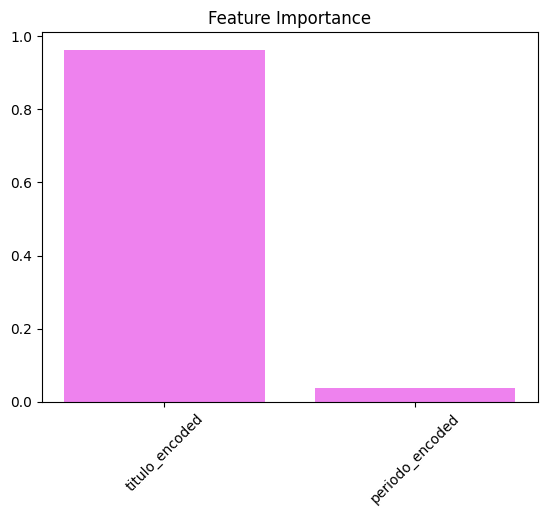

In [55]:

plt.figure()
plt.bar(df_importancia["Feature"], df_importancia["Importância"], color='violet')
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()